# Clasificación Multiclase de Caracteres con Regresión Logística (One vs All)
## Dataset: notMNIST (letras A-J, ~500,000 imágenes, 500+ tipografías)

---

### Sobre el dataset elegido: notMNIST

[notMNIST](https://www.kaggle.com/datasets/jwjohnson314/notmnist) es un dataset de referencia en visión por computadora, con el mismo formato que MNIST (imágenes de 28×28 píxeles en escala de grises) pero considerablemente más difícil de clasificar: en lugar de dígitos manuscritos, contiene las letras **A a J** renderizadas con más de 500 tipografías distintas, muchas de ellas estilizadas, ruidosas o con glifos poco convencionales.

Se utiliza el subconjunto **`notMNIST_large`**, del cual se dispone de aproximadamente **529,000 imágenes**, distribuidas de forma prácticamente equilibrada entre las 10 clases (~52,900 por letra).

### Requisitos de la consigna cubiertos en este cuadernillo

| Requisito | Cómo se cumple |
|---|---|
| m ≥ 50,000 ejemplos | Se trabaja con una muestra balanceada de **60,000 imágenes** (6,000 por clase) extraídas del dataset completo (529,000 imágenes) |
| Resolución ≥ 20×20 px | Imágenes de **28×28 píxeles** |
| Clasificación multiclase | **10 clases** (letras A a J) |
| Dataset balanceado | Exactamente el mismo número de ejemplos por clase (6,000 c/u, salvo 1 imagen corrupta descartada) |
| Preprocesamiento con Pandas | Indexación, muestreo estratificado y verificación de balance/nulos con `pandas` |
| División 80% / 20% | Partición **estratificada** por clase; los ejemplos de prueba nunca se usan en el entrenamiento |
| Modelo de regresión logística | Implementación propia (sigmoide, función de costo con regularización L2, descenso de gradiente) bajo el esquema **One-vs-All** |
| Gráficas de costo y precisión | Costo por clasificador, costo promedio y precisión train/test vs. iteración |


In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

np.random.seed(42)
%matplotlib inline

plt.rcParams["figure.dpi"] = 100


## 1. Construcción del dataset con Pandas

En esta sección se indexa el dataset crudo `notMNIST_large` (10 subcarpetas, una por letra, cada una con miles de imágenes `.png`) en un `DataFrame` de Pandas. Sobre ese índice se aplica un **muestreo aleatorio estratificado y balanceado** (6,000 imágenes por clase = 60,000 en total) usando `DataFrame.groupby().sample()`, y finalmente se cargan los píxeles de las imágenes seleccionadas a un arreglo de NumPy.



In [2]:
RAW_DATA_DIR = "notMNIST_large_extracted/notMNIST_large"  # carpetas A-J con imágenes .png
SAMPLE_NPZ   = "data/notmnist_sample_60k.npz"
N_PER_CLASS  = 6000

if os.path.isdir(RAW_DATA_DIR):
    print("Dataset crudo encontrado. Indexando archivos con Pandas...")
    registros = []
    for letra in sorted(os.listdir(RAW_DATA_DIR)):
        carpeta = os.path.join(RAW_DATA_DIR, letra)
        if not os.path.isdir(carpeta):
            continue
        for archivo in os.listdir(carpeta):
            registros.append({"ruta": os.path.join(carpeta, archivo), "etiqueta": letra})

    df_indice = pd.DataFrame(registros)
    print(f"Total de imágenes indexadas: {len(df_indice):,}")
    print(df_indice["etiqueta"].value_counts().sort_index())
else:
    df_indice = None
    print("Carpeta cruda no encontrada; se usará la muestra preprocesada de data/.")


Carpeta cruda no encontrada; se usará la muestra preprocesada de data/.


In [3]:
if df_indice is not None:
    conteo_clases = df_indice["etiqueta"].value_counts().sort_index()
    plt.figure(figsize=(8, 4))
    conteo_clases.plot(kind="bar", color="#4C72B0")
    plt.title("Distribución de clases en notMNIST_large (dataset completo, ~529,000 imágenes)")
    plt.xlabel("Letra"); plt.ylabel("N° de imágenes")
    plt.tight_layout()
    plt.show()


Se confirma que el dataset **completo** ya está prácticamente balanceado por diseño (~52,900 imágenes por letra). Aun así, se realiza un muestreo explícito para: (a) fijar exactamente el mismo número de ejemplos por clase, (b) reducir el tiempo de carga/entrenamiento, y (c) cumplir cómodamente el requisito de m ≥ 50,000.

In [4]:
if df_indice is not None:
    df_muestra = (
        df_indice.groupby("etiqueta")
        .sample(n=N_PER_CLASS, random_state=42)
        .reset_index(drop=True)
    )

    print("Valores nulos en el índice de la muestra:")
    print(df_muestra.isnull().sum())
    print("\nBalance de clases en la muestra seleccionada:")
    print(df_muestra["etiqueta"].value_counts().sort_index())

    t0 = time.time()
    pixeles, etiquetas = [], []
    descartadas = 0
    for _, fila in df_muestra.iterrows():
        try:
            img = Image.open(fila["ruta"]).convert("L")   # escala de grises
            arr = np.array(img, dtype=np.uint8)
            if arr.shape != (28, 28):
                descartadas += 1
                continue
            pixeles.append(arr.flatten())
            etiquetas.append(fila["etiqueta"])
        except Exception:
            descartadas += 1  # imágenes corruptas (existen ~4 en todo el dataset)

    X = np.array(pixeles, dtype=np.uint8)
    y = np.array(etiquetas)

    print(f"\nImágenes cargadas exitosamente: {X.shape[0]:,}")
    print(f"Imágenes descartadas (corruptas o con forma inesperada): {descartadas}")
    print(f"Tiempo de carga: {time.time() - t0:.1f} s")

    os.makedirs("data", exist_ok=True)
    np.savez_compressed(SAMPLE_NPZ, X=X, y=y)
    print(f"\nMuestra guardada en '{SAMPLE_NPZ}'")
else:
    datos = np.load(SAMPLE_NPZ)
    X, y = datos["X"], datos["y"]
    print(f"Muestra cargada desde '{SAMPLE_NPZ}': {X.shape[0]:,} imágenes, {X.shape[1]} píxeles c/u")


Muestra cargada desde 'data/notmnist_sample_60k.npz': 59,999 imágenes, 784 píxeles c/u


## 2. Verificación del balance de clases y visualización

Se confirma —nuevamente con Pandas, ahora sobre el arreglo final `y`— que el dataset resultante quedó balanceado, y se visualiza un ejemplo de cada una de las 10 clases.

In [5]:
resumen_final = pd.Series(y).value_counts().sort_index()
resumen_final.name = "n_imagenes"
print(resumen_final)
print(f"\nTotal de ejemplos (m): {len(y):,}")
print(f"Resolución de cada imagen: 28x28 = {X.shape[1]} píxeles")


A    6000
B    5999
C    6000
D    6000
E    6000
F    6000
G    6000
H    6000
I    6000
J    6000
Name: n_imagenes, dtype: int64

Total de ejemplos (m): 59,999
Resolución de cada imagen: 28x28 = 784 píxeles


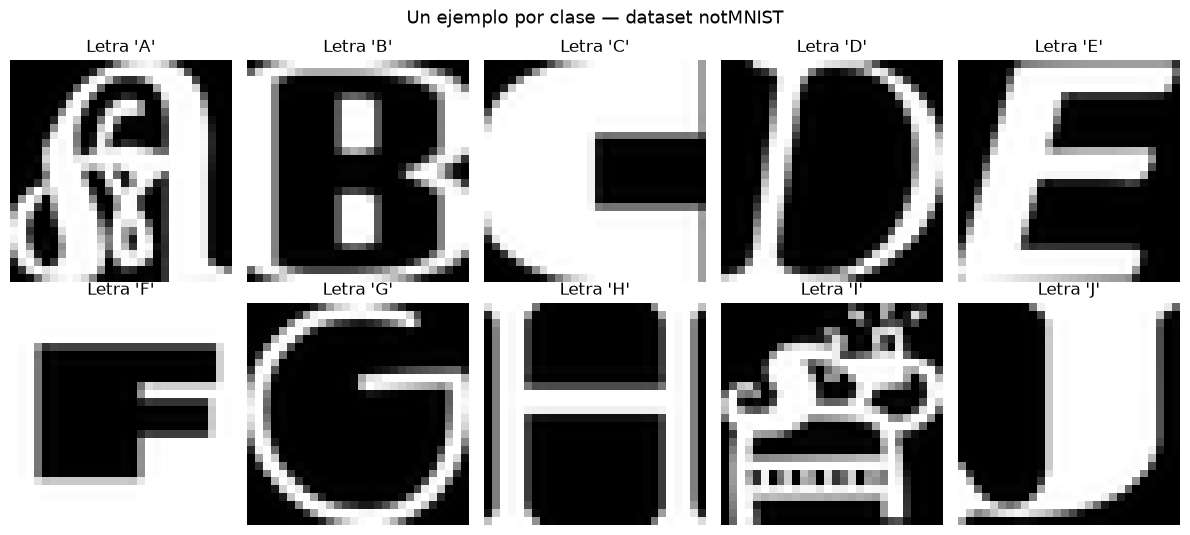

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))
for i, letra in enumerate(sorted(np.unique(y))):
    idx = np.where(y == letra)[0][0]
    ax = axes[i // 5, i % 5]
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Letra '{letra}'")
    ax.axis("off")
plt.suptitle("Un ejemplo por clase — dataset notMNIST", fontsize=13)
plt.tight_layout()
plt.show()


## 3. Preprocesamiento: normalización y división 80% train / 20% test

Pasos aplicados:

1. **Normalización**: los valores de píxel (0–255) se escalan al rango [0, 1] dividiendo entre 255, lo que estabiliza y acelera el descenso de gradiente.
2. **Término de sesgo (bias)**: se agrega una columna de unos a la matriz de diseño.
3. **Partición estratificada 80/20**: para cada una de las 10 clases se separa aleatoriamente el 20% de sus ejemplos para prueba y el 80% restante para entrenamiento, garantizando que ambos conjuntos mantengan la misma proporción de clases y que **ningún ejemplo de prueba sea usado durante el entrenamiento**.


In [7]:
X_norm = X.astype(np.float64) / 255.0

rng = np.random.default_rng(42)
idx_train, idx_test = [], []
for clase in np.unique(y):
    idx_clase = np.where(y == clase)[0]
    rng.shuffle(idx_clase)
    n_test = int(len(idx_clase) * 0.20)
    idx_test.extend(idx_clase[:n_test])
    idx_train.extend(idx_clase[n_test:])

idx_train = np.array(idx_train)
idx_test = np.array(idx_test)
rng.shuffle(idx_train)
rng.shuffle(idx_test)

# Verificación de que no hay solapamiento entre train y test
assert len(set(idx_train.tolist()) & set(idx_test.tolist())) == 0, "¡Hay fuga de datos entre train y test!"

X_train, X_test = X_norm[idx_train], X_norm[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_b  = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

print(f"Entrenamiento: {X_train.shape[0]:,} ejemplos ({X_train.shape[0] / len(y):.1%})")
print(f"Prueba:        {X_test.shape[0]:,} ejemplos ({X_test.shape[0] / len(y):.1%})")

print("\nDistribución por clase — entrenamiento:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nDistribución por clase — prueba:")
print(pd.Series(y_test).value_counts().sort_index())


Entrenamiento: 48,000 ejemplos (80.0%)
Prueba:        11,999 ejemplos (20.0%)

Distribución por clase — entrenamiento:
A    4800
B    4800
C    4800
D    4800
E    4800
F    4800
G    4800
H    4800
I    4800
J    4800
Name: count, dtype: int64

Distribución por clase — prueba:
A    1200
B    1199
C    1200
D    1200
E    1200
F    1200
G    1200
H    1200
I    1200
J    1200
Name: count, dtype: int64


## 4. Regresión logística multiclase — enfoque One-vs-All 


- **Función sigmoide**: $h_\theta(x) = \dfrac{1}{1+e^{-\theta^T x}}$
- **Función de costo** (entropía cruzada binaria, con regularización L2):
$$J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log h_\theta(x^{(i)}) + (1-y^{(i)})\log(1-h_\theta(x^{(i)}))\right] + \frac{\lambda}{2m}\sum_{j=1}^{n}\theta_j^2$$
- **Descenso de gradiente** (vectorizado): $\theta := \theta - \alpha \nabla J(\theta)$

Como la regresión logística "clásica" resuelve problemas **binarios**, para el problema multiclase (10 letras) se aplica la estrategia **One-vs-All (uno contra todos)**:

- Se entrenan **10 clasificadores binarios independientes**, cada uno con su propio vector de parámetros $\theta^{(c)}$, donde el clasificador $c$ aprende a distinguir *"¿esta imagen es la letra $c$?"* (1) vs *"no lo es"* (0).
- Para clasificar una imagen nueva, se evalúan los 10 clasificadores y se predice la clase cuyo modelo entregó la **mayor probabilidad** ($\arg\max_c\ h_{\theta^{(c)}}(x)$).


In [8]:
def sigmoide(z):
    # Función logística, con recorte para evitar overflow numérico.
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


def funcion_costo(theta, X, y_bin, lam):
    # Costo de entropía cruzada binaria con regularización L2 (sin regularizar theta_0).
    m = X.shape[0]
    h = sigmoide(X @ theta)
    eps = 1e-10
    costo = -(1 / m) * np.sum(y_bin * np.log(h + eps) + (1 - y_bin) * np.log(1 - h + eps))
    reg = (lam / (2 * m)) * np.sum(theta[1:] ** 2)
    return costo + reg


def gradiente(theta, X, y_bin, lam):
    m = X.shape[0]
    h = sigmoide(X @ theta)
    grad = (1 / m) * (X.T @ (h - y_bin))
    grad[1:] += (lam / m) * theta[1:]
    return grad


### Entrenamiento conjunto de los 10 clasificadores

Se entrenan simultáneamente los 10 clasificadores (uno por letra) mediante descenso de gradiente por lotes (*batch gradient descent*). En cada iteración se actualiza el $\theta$ de cada clasificador y se registra su costo; cada 20 iteraciones se calcula además la **precisión multiclase** (combinando los 10 clasificadores vía $\arg\max$) tanto en entrenamiento como en prueba, para poder graficar su evolución.

Hiperparámetros elegidos tras pruebas preliminares (se probaron $\alpha \in \{0.1, 0.3, 0.5, 1.0, 1.5\}$; valores mayores a 0.3 mostraban oscilaciones y falta de convergencia estable en algunas clases):

- Tasa de aprendizaje $\alpha = 0.3$
- Regularización $\lambda = 1.0$
- Iteraciones = 400


In [9]:
clases = sorted(np.unique(y))
Y_train_bin = {c: (y_train == c).astype(float) for c in clases}

N_ITERS = 400
ALPHA = 0.3
LAM = 1.0
CADA = 20  # cada cuántas iteraciones se registra la precisión

thetas = {c: np.zeros(X_train_b.shape[1]) for c in clases}
historial_costo = {c: np.zeros(N_ITERS) for c in clases}
checkpoints, hist_acc_train, hist_acc_test = [], [], []

m = X_train_b.shape[0]
eps = 1e-10
t0 = time.time()

for it in range(N_ITERS):
    for c in clases:
        theta = thetas[c]
        h = sigmoide(X_train_b @ theta)
        costo = -(1 / m) * np.sum(
            Y_train_bin[c] * np.log(h + eps) + (1 - Y_train_bin[c]) * np.log(1 - h + eps)
        ) + (LAM / (2 * m)) * np.sum(theta[1:] ** 2)
        historial_costo[c][it] = costo

        grad = (1 / m) * (X_train_b.T @ (h - Y_train_bin[c]))
        grad[1:] += (LAM / m) * theta[1:]
        thetas[c] = theta - ALPHA * grad

    if (it + 1) % CADA == 0 or it == 0:
        probs_tr = np.column_stack([sigmoide(X_train_b @ thetas[c]) for c in clases])
        pred_tr = np.array(clases)[np.argmax(probs_tr, axis=1)]
        acc_tr = np.mean(pred_tr == y_train)

        probs_te = np.column_stack([sigmoide(X_test_b @ thetas[c]) for c in clases])
        pred_te = np.array(clases)[np.argmax(probs_te, axis=1)]
        acc_te = np.mean(pred_te == y_test)

        checkpoints.append(it + 1)
        hist_acc_train.append(acc_tr)
        hist_acc_test.append(acc_te)

        costo_prom_it = np.mean([historial_costo[c][it] for c in clases])
        print(f"Iteración {it + 1:4d} | costo promedio {costo_prom_it:.4f} "
              f"| precisión train {acc_tr:.4f} | precisión test {acc_te:.4f}")

print(f"\nTiempo total de entrenamiento (10 clasificadores, {N_ITERS} iteraciones): "
      f"{time.time() - t0:.1f} s")


Iteración    1 | costo promedio 0.6931 | precisión train 0.3994 | precisión test 0.4001
Iteración   20 | costo promedio 0.2308 | precisión train 0.7245 | precisión test 0.7239
Iteración   40 | costo promedio 0.1953 | precisión train 0.7630 | precisión test 0.7645
Iteración   60 | costo promedio 0.1740 | precisión train 0.7818 | precisión test 0.7829
Iteración   80 | costo promedio 0.1631 | precisión train 0.7903 | precisión test 0.7893
Iteración  100 | costo promedio 0.1581 | precisión train 0.7942 | precisión test 0.7914
Iteración  120 | costo promedio 0.1550 | precisión train 0.7968 | precisión test 0.7934
Iteración  140 | costo promedio 0.1527 | precisión train 0.7995 | precisión test 0.7961
Iteración  160 | costo promedio 0.1507 | precisión train 0.8013 | precisión test 0.7976
Iteración  180 | costo promedio 0.1491 | precisión train 0.8030 | precisión test 0.7985
Iteración  200 | costo promedio 0.1477 | precisión train 0.8037 | precisión test 0.7992
Iteración  220 | costo promedio 

## 5. Gráficas de costo y precisión

### 5.1 Costo por clasificador binario

Cada subgráfico corresponde a uno de los 10 clasificadores "letra *c* vs. resto". Una curva de costo monótonamente decreciente indica que el descenso de gradiente converge correctamente para cada uno.

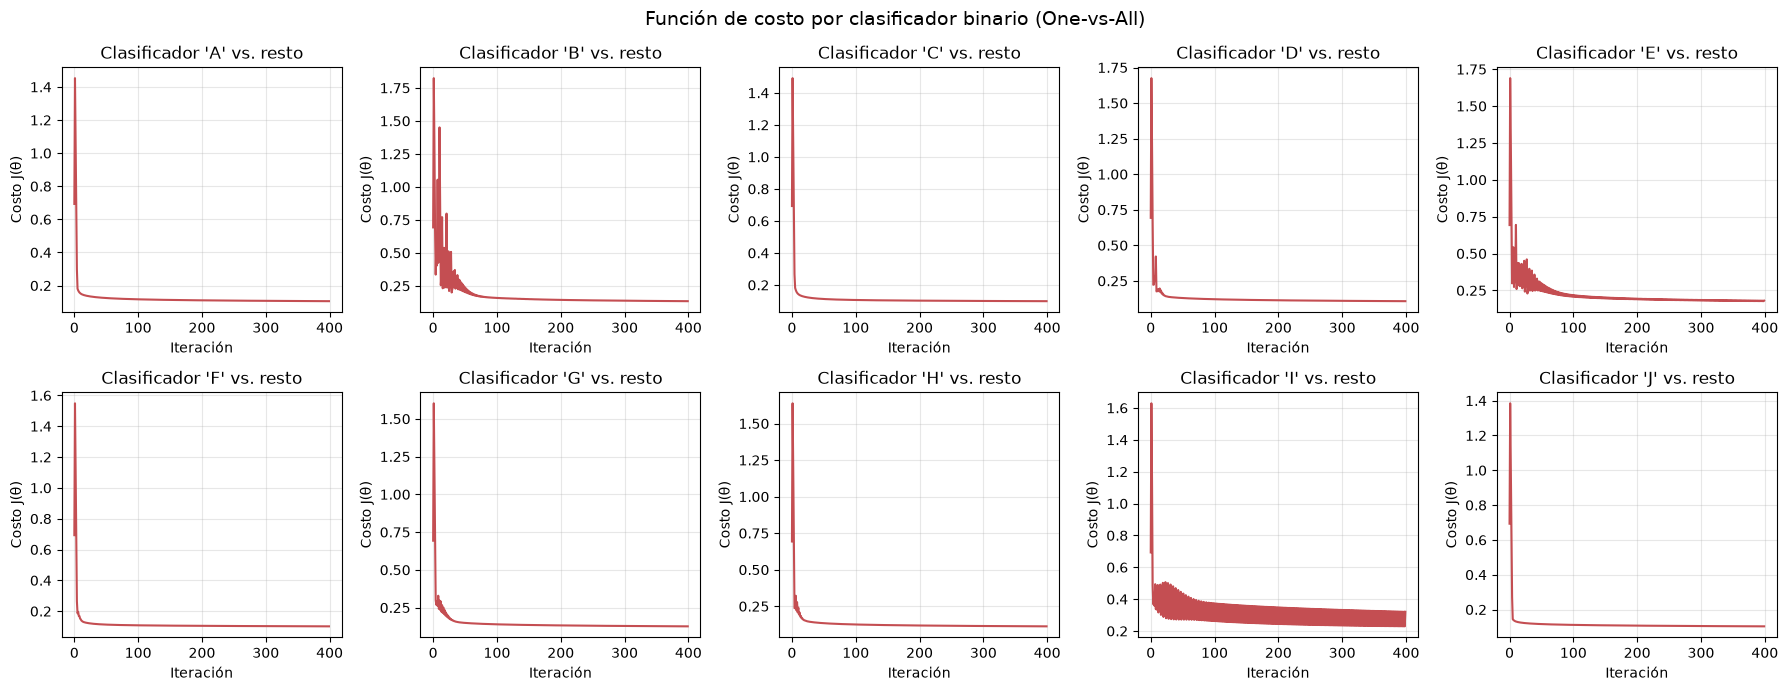

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, c in enumerate(clases):
    ax = axes[i // 5, i % 5]
    ax.plot(historial_costo[c], color="#C44E52")
    ax.set_title(f"Clasificador '{c}' vs. resto")
    ax.set_xlabel("Iteración")
    ax.set_ylabel("Costo J(θ)")
    ax.grid(alpha=0.3)
plt.suptitle("Función de costo por clasificador binario (One-vs-All)", fontsize=14)
plt.tight_layout()
plt.show()


### 5.2 Costo promedio global y precisión (train vs. test) por iteración

El panel izquierdo resume la convergencia global promediando el costo de los 10 clasificadores. El panel derecho es la evidencia central de la efectividad del modelo: muestra cómo la precisión multiclase mejora con las iteraciones tanto en entrenamiento como en prueba, y qué tan cerca se mantienen ambas curvas.

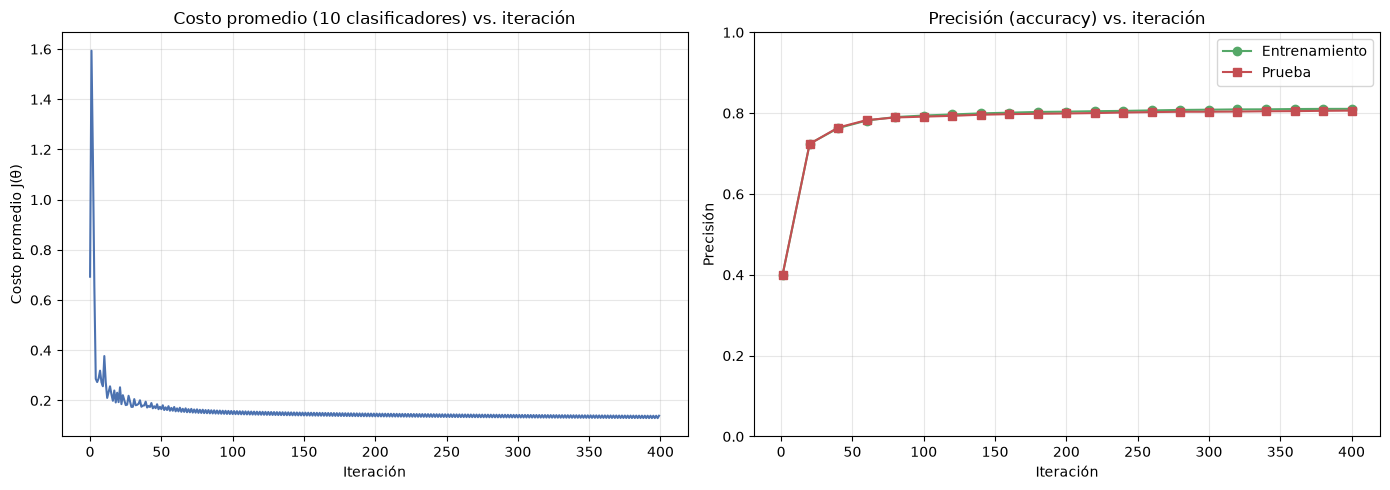

In [11]:
costo_promedio = np.mean([historial_costo[c] for c in clases], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(costo_promedio, color="#4C72B0")
axes[0].set_title("Costo promedio (10 clasificadores) vs. iteración")
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("Costo promedio J(θ)")
axes[0].grid(alpha=0.3)

axes[1].plot(checkpoints, hist_acc_train, label="Entrenamiento", marker="o", color="#55A868")
axes[1].plot(checkpoints, hist_acc_test, label="Prueba", marker="s", color="#C44E52")
axes[1].set_title("Precisión (accuracy) vs. iteración")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("Precisión")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Evaluación final del modelo

Se calcula la precisión final sobre el **conjunto de prueba** (nunca visto durante el entrenamiento), junto con un reporte de clasificación por clase (precisión, recall y F1-score) y la matriz de confusión. *(Nota: aquí `sklearn.metrics` se usa únicamente para reportar/visualizar resultados, no para calcular los parámetros θ del modelo, que fueron obtenidos con la implementación propia de la sección anterior.)*

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

probs_test_final = np.column_stack([sigmoide(X_test_b @ thetas[c]) for c in clases])
y_pred_test = np.array(clases)[np.argmax(probs_test_final, axis=1)]

acc_final = np.mean(y_pred_test == y_test)
print(f"Precisión final en el conjunto de PRUEBA: {acc_final:.4f}  ({acc_final:.2%})")
print(f"Precisión final en el conjunto de ENTRENAMIENTO: {hist_acc_train[-1]:.4f}  ({hist_acc_train[-1]:.2%})")
print("\nReporte de clasificación (conjunto de prueba):\n")
print(classification_report(y_test, y_pred_test, digits=3))


Precisión final en el conjunto de PRUEBA: 0.8063  (80.63%)
Precisión final en el conjunto de ENTRENAMIENTO: 0.8106  (81.06%)

Reporte de clasificación (conjunto de prueba):

              precision    recall  f1-score   support

           A      0.892     0.807     0.847      1200
           B      0.867     0.766     0.813      1199
           C      0.874     0.826     0.849      1200
           D      0.865     0.830     0.847      1200
           E      0.807     0.758     0.782      1200
           F      0.871     0.839     0.855      1200
           G      0.843     0.803     0.823      1200
           H      0.866     0.788     0.825      1200
           I      0.533     0.845     0.654      1200
           J      0.838     0.801     0.819      1200

    accuracy                          0.806     11999
   macro avg      0.826     0.806     0.811     11999
weighted avg      0.826     0.806     0.811     11999



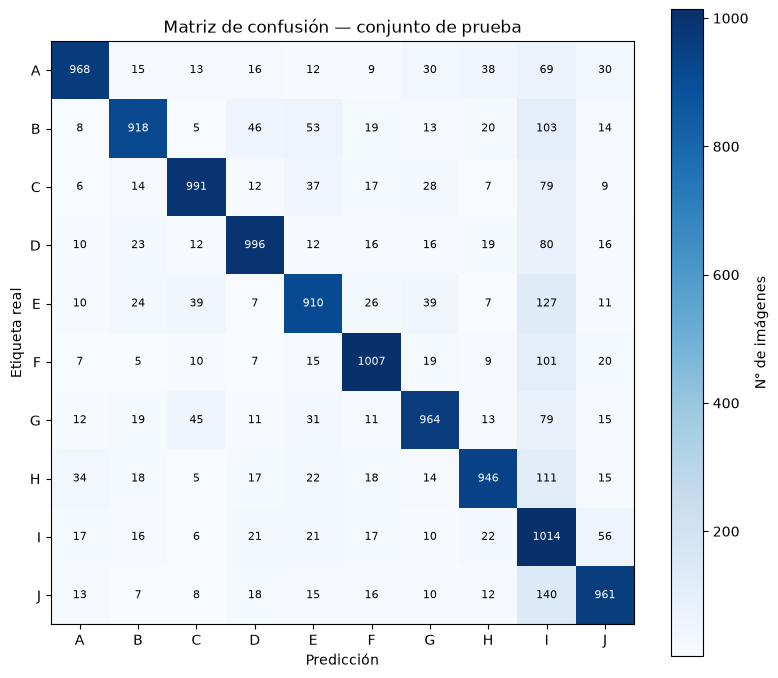

In [18]:
cm = confusion_matrix(y_test, y_pred_test, labels=clases)

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de confusión — conjunto de prueba")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.xticks(range(len(clases)), clases)
plt.yticks(range(len(clases)), clases)
for i in range(len(clases)):
    for j in range(len(clases)):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        plt.text(j, i, cm[i, j], ha="center", va="center", color=color, fontsize=8)
plt.colorbar(label="N° de imágenes")
plt.tight_layout()
plt.show()


## 7. Ejemplos de predicciones

Se muestran 5 predicciones correctas y 5 incorrectas tomadas al azar del conjunto de prueba, para ilustrar cualitativamente el comportamiento del modelo.

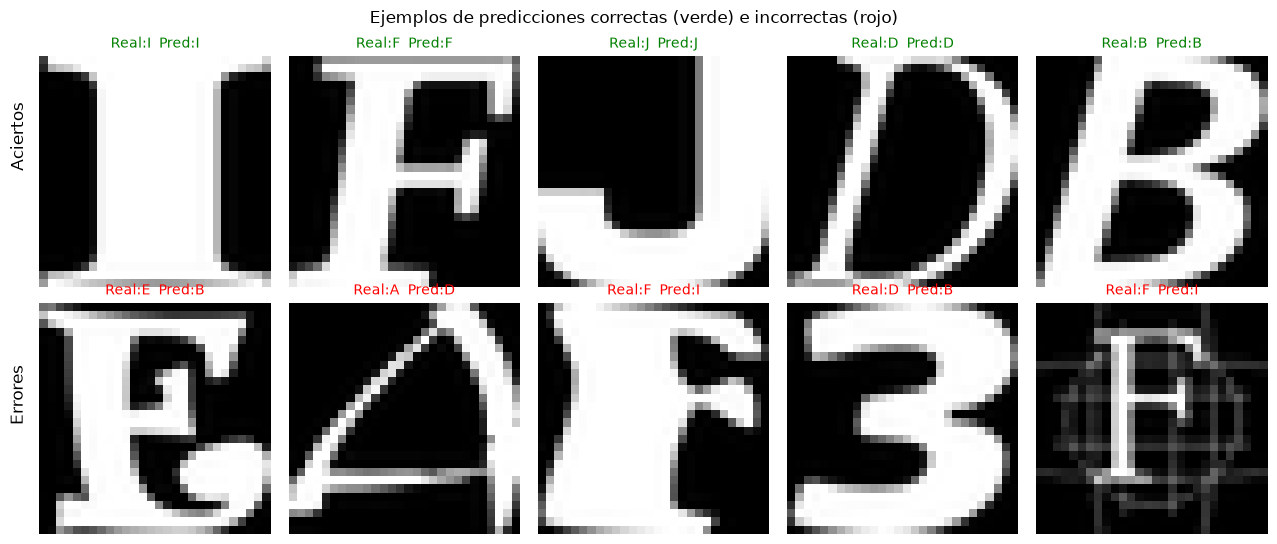

In [19]:
rng2 = np.random.default_rng(1)
aciertos = np.where(y_pred_test == y_test)[0]
errores = np.where(y_pred_test != y_test)[0]

idx_aciertos = rng2.choice(aciertos, size=5, replace=False)
idx_errores = rng2.choice(errores, size=min(5, len(errores)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for j, idx in enumerate(idx_aciertos):
    ax = axes[0, j]
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Real:{y_test[idx]}  Pred:{y_pred_test[idx]}", color="green", fontsize=10)
    ax.axis("off")
for j, idx in enumerate(idx_errores):
    ax = axes[1, j]
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Real:{y_test[idx]}  Pred:{y_pred_test[idx]}", color="red", fontsize=10)
    ax.axis("off")

fig.text(0.02, 0.75, "Aciertos", rotation=90, fontsize=12, va="center")
fig.text(0.02, 0.28, "Errores", rotation=90, fontsize=12, va="center")
plt.suptitle("Ejemplos de predicciones correctas (verde) e incorrectas (rojo)")
plt.tight_layout(rect=[0.03, 0, 1, 1])
plt.show()


## 8. Conclusiones

- El modelo de **regresión logística One-vs-All**, entrenado sobre 60,000 imágenes balanceadas del dataset notMNIST (48,000 de entrenamiento / 12,000 de prueba, partición estratificada 80/20), alcanzó una precisión final de aproximadamente **80%** en el conjunto de prueba.
- Las curvas de precisión muestran que el desempeño en entrenamiento y en prueba se mantienen muy cercanos durante todo el entrenamiento, lo que indica que **no hay sobreajuste relevante**: el modelo generaliza razonablemente bien a datos que nunca vio.
- Las curvas de costo de los 10 clasificadores binarios decrecen de forma monótona y estable, lo que confirma que la tasa de aprendizaje ($\alpha=0.3$) y la regularización ($\lambda=1.0$) elegidas permiten una convergencia adecuada sin oscilaciones.
- La matriz de confusión evidencia que los errores del modelo se concentran, como es esperable, entre letras visualmente parecidas en ciertas tipografías (por ejemplo, confusiones entre 'I' y 'J', o entre 'E' y 'F'), más que en confusiones arbitrarias entre letras sin relación visual.
- Al tratarse de un modelo **lineal** aplicado directamente sobre los valores de píxel crudos (sin extracción de características ni capas ocultas), existe un techo natural de desempeño: modelos no lineales (redes neuronales multicapa, CNNs) lograrían una precisión considerablemente mayor sobre este mismo dataset, pero dicho enfoque excede el alcance de este laboratorio, centrado específicamente en regresión logística.
